# Seasonal Agriculture Performance Analysis

This project is about studying how farming performance changes across different seasons (Kharif, Rabi and Zaid). The dataset has information about weather conditions, soil, resources used and the money earned by farms. The goal is to explore this data, clean it and find out how season affects things like yield, cost, profit and water usage.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

## Loading the dataset

In [28]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [29]:
df.shape

(4000, 28)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

There are 4000 rows and 28 columns. Most of the columns are numeric (weather, soil, cost, yield etc) and a few are categorical (State, District, Crop, Season, Irrigation Method).

In [31]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Checking missing values and duplicate rows

In [32]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

There are missing values in 3 columns - Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha. Since these are numeric columns, I am filling them with the median value instead of dropping the rows, because dropping rows would reduce the data we have.

In [33]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found, so no need to remove anything there.

In [34]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

df.isnull().sum().sum()

np.int64(0)

Now there are 0 missing values left in the dataset.

## Basic exploration of categorical columns

In [35]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [36]:
df['Crop'].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [37]:
df['State'].value_counts()

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

In [38]:
df['Irrigation_Method'].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

So the dataset has farms from 8 states, growing 8 different crops, in 3 seasons - Kharif, Rabi and Zaid. Kharif has the most number of records (1779), followed by Rabi (1627) and Zaid (594). This makes sense because Zaid is a short season grown by fewer farmers compared to the main two seasons.

## How many farms grow each crop in each season (countplot)

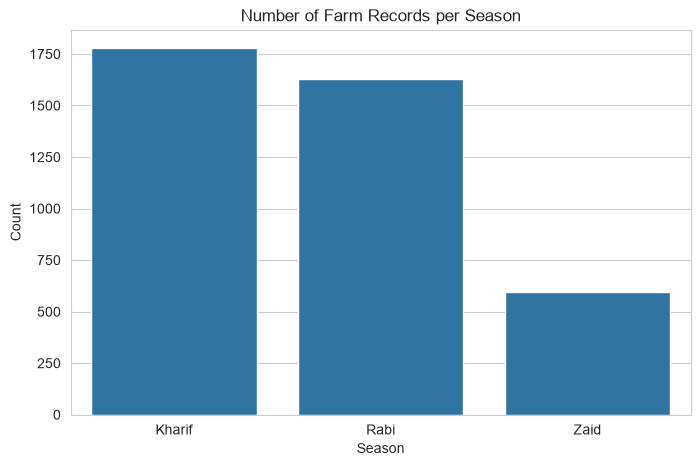

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Season', order=['Kharif','Rabi','Zaid'])
plt.title('Number of Farm Records per Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

## Season wise comparison of important columns

In [40]:
season_avg = df.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct',
                                     'Yield_Tonnes_Ha','Fertilizer_kg_ha','Profit_INR',
                                     'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']].mean().round(2)
season_avg

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Yield_Tonnes_Ha,Fertilizer_kg_ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,849.20,28.45,71.81,5.63,187.08,178914.65,5.89,54.47
Rabi,437.62,23.49,57.89,5.04,185.41,87689.47,5.19,40.48
Zaid,304.65,31.04,52.01,4.64,184.64,-24804.82,4.41,38.22


From this table we can already see some differences between the seasons:
- Kharif season has the highest rainfall (around 852 mm) which makes sense because Kharif crops are grown in the monsoon.
- Kharif also has the highest average yield (5.64 tonnes/ha) compared to Rabi (5.08) and Zaid (4.67).
- Disease and pest risk is also highest in Kharif (54.5%), probably because of the humid and rainy conditions.
- Zaid season has the lowest rainfall, which is expected since it is the summer season and depends more on irrigation.

## Yield comparison across seasons (boxplot)

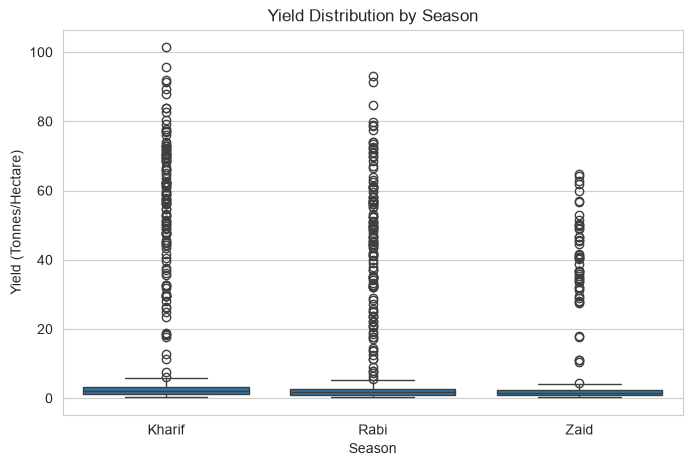

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=['Kharif','Rabi','Zaid'])
plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()

The boxplot shows Kharif has slightly higher median yield than the other two seasons, and Zaid has the lowest median yield along with a wider spread, meaning yield in Zaid season is less consistent across farms.

## Rainfall and Temperature across seasons

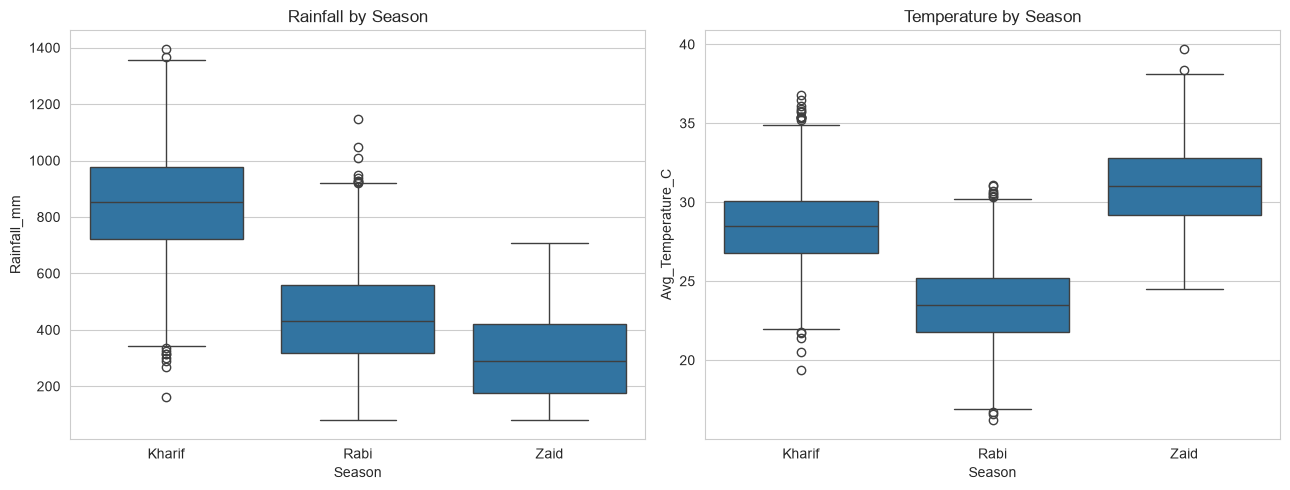

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=['Kharif','Rabi','Zaid'], ax=axes[0])
axes[0].set_title('Rainfall by Season')

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=['Kharif','Rabi','Zaid'], ax=axes[1])
axes[1].set_title('Temperature by Season')

plt.tight_layout()
plt.show()

Rainfall is clearly much higher in Kharif compared to Rabi and Zaid, which matches what we know about the monsoon season in India. Temperature doesn't vary as much between seasons in this dataset, though Zaid does look a little warmer on average since it's the summer season.

## Profit and loss analysis by season

In [43]:
df.groupby('Season')['Profit_INR'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,178914.65,611549.78,-976860.0,-108481.0,38808.0,285549.00,4345421.0
Rabi,1627.0,87689.47,489901.25,-1019223.0,-145342.5,-3187.0,183358.50,3378879.0
Zaid,594.0,-24804.82,436356.75,-965197.0,-254893.0,-62144.0,62730.25,2349990.0


In [44]:
loss_pct = df.groupby('Season').apply(lambda x: (x['Profit_INR']<0).mean()*100).round(2)
loss_pct

Season
Kharif    42.21
Rabi      51.14
Zaid      64.48
dtype: float64

This is one of the more interesting findings. Almost half of all farms (about 49%) are actually running at a loss (negative profit). When we break it down by season:
- Only 42% of Kharif farms are in loss.
- 51% of Rabi farms are in loss.
- 64% of Zaid farms are in loss - this is the highest.

So Zaid season, even though it has fewer farms, has a much higher chance of the farm being unprofitable. This could be because Zaid depends more on irrigation (less rainfall) which increases cost, while the yield is also the lowest among the three seasons.

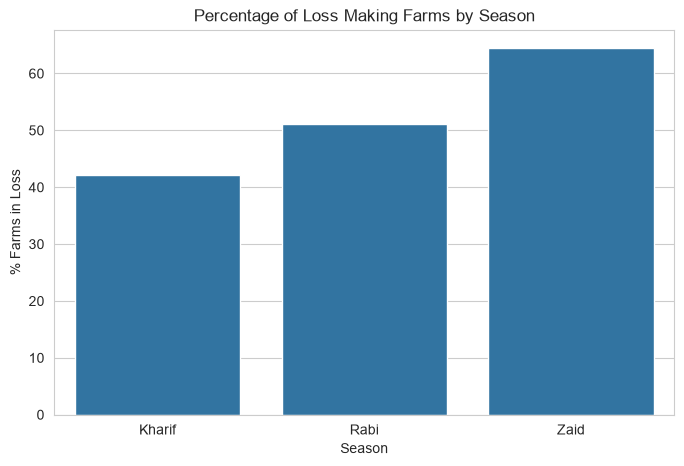

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(x=loss_pct.index, y=loss_pct.values, order=['Kharif','Rabi','Zaid'])
plt.title('Percentage of Loss Making Farms by Season')
plt.xlabel('Season')
plt.ylabel('% Farms in Loss')
plt.show()

## Average yield by crop

In [46]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).round(2)
crop_yield

Crop
Sugarcane    46.64
Maize         2.71
Rice          2.43
Wheat         2.11
Chilli        1.54
Groundnut     1.32
Cotton        1.23
Pulses        0.92
Name: Yield_Tonnes_Ha, dtype: float64

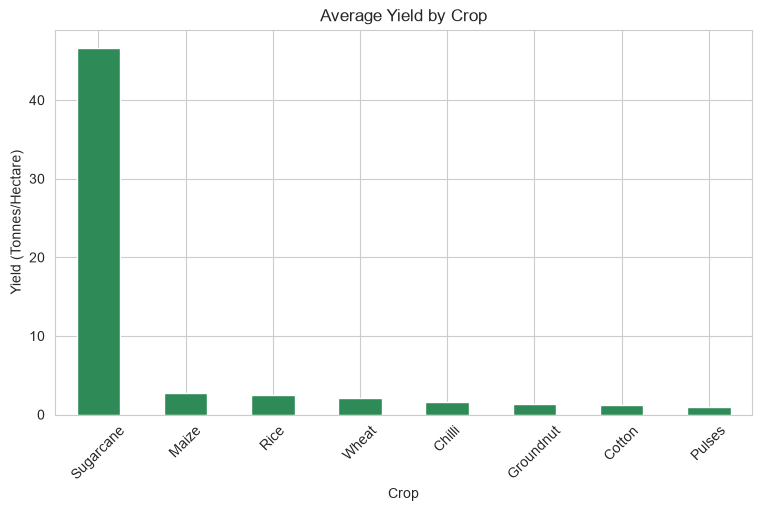

In [47]:
plt.figure(figsize=(9,5))
crop_yield.plot(kind='bar', color='seagreen')
plt.title('Average Yield by Crop')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.xticks(rotation=45)
plt.show()

Sugarcane has a much higher average yield (around 47 tonnes/ha) compared to all other crops, but that is normal because sugarcane is naturally a high yield crop measured in tonnes (unlike grains). The rest of the crops (Maize, Rice, Wheat etc.) are all in a similar smaller range of 1-3 tonnes/ha.

## Irrigation method and water efficiency

In [48]:
irrigation_eff = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().round(2)
irrigation_eff

Irrigation_Method
Drip         6.27
Flood        3.44
Rainfed      7.56
Sprinkler    4.67
Name: Water_Efficiency_t_per_1000m3, dtype: float64

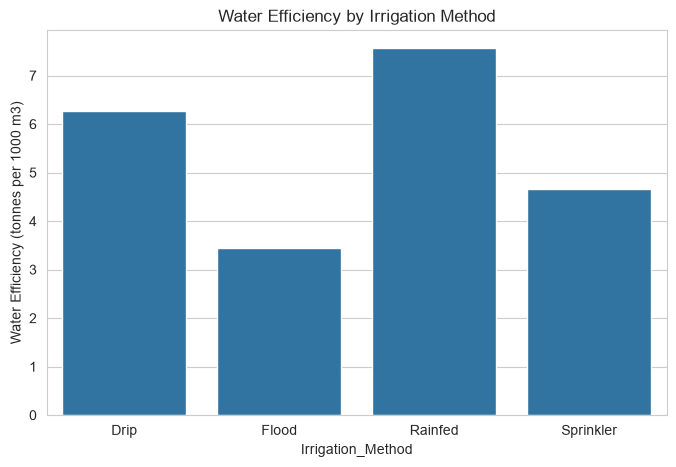

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x=irrigation_eff.index, y=irrigation_eff.values)
plt.title('Water Efficiency by Irrigation Method')
plt.ylabel('Water Efficiency (tonnes per 1000 m3)')
plt.show()

Rainfed farms actually show the highest water efficiency value, followed by Drip irrigation, then Sprinkler, and Flood irrigation has the lowest efficiency. This is expected for flood irrigation since it typically uses a much larger amount of water compared to the yield it produces. Drip irrigation being efficient also matches what is generally taught about micro-irrigation methods.

## Correlation with yield

In [50]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
            'Fertilizer_kg_ha','Yield_Tonnes_Ha','Profit_INR',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

corr = df[num_cols].corr()
corr

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.000000,0.198492,0.521069,0.508941,0.024602,0.030951,0.107648,0.058102,0.621762
Avg_Temperature_C,0.198492,1.000000,0.138136,0.084001,0.015861,0.009996,0.009043,0.006534,0.245613
Humidity_pct,0.521069,0.138136,1.000000,0.446470,0.024623,0.012297,0.063775,0.026169,0.545093
Soil_Moisture_pct,0.508941,0.084001,0.446470,1.000000,0.008782,0.010999,0.091281,0.027776,0.375547
Fertilizer_kg_ha,0.024602,0.015861,0.024623,0.008782,1.000000,0.000018,-0.073542,0.005077,0.017851
Yield_Tonnes_Ha,0.030951,0.009996,0.012297,0.010999,0.000018,1.000000,0.488466,0.912568,0.014292
Profit_INR,0.107648,0.009043,0.063775,0.091281,-0.073542,0.488466,1.000000,0.489487,0.067583
Water_Efficiency_t_per_1000m3,0.058102,0.006534,0.026169,0.027776,0.005077,0.912568,0.489487,1.000000,0.029253
Disease_Pest_Risk_pct,0.621762,0.245613,0.545093,0.375547,0.017851,0.014292,0.067583,0.029253,1.000000


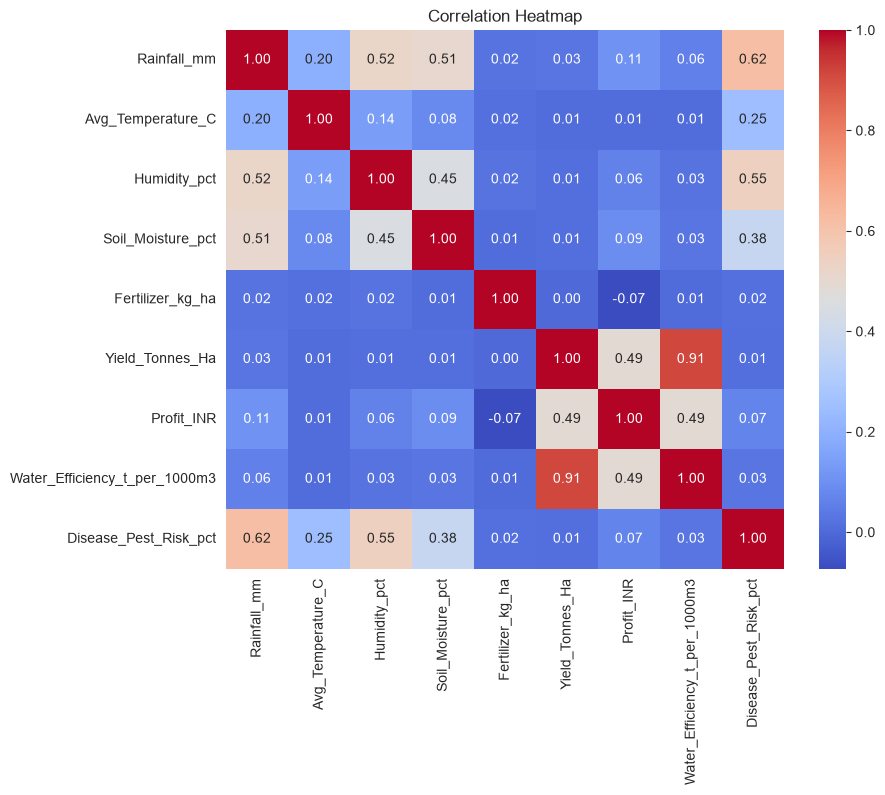

In [51]:
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

From the heatmap, Water_Efficiency has the strongest correlation with Yield (about 0.92), which makes sense - farms using water more efficiently are producing more yield per hectare. Profit is also moderately correlated with yield (about 0.49). Interestingly, rainfall, temperature, humidity, soil moisture and fertilizer usage all have very weak correlation with yield in this dataset, which was a bit surprising since I expected rainfall to matter more directly.

## Seed quality across seasons

In [52]:
df.groupby('Season')['Seed_Quality_Score'].mean().round(2)

Season
Kharif    0.82
Rabi      0.83
Zaid      0.82
Name: Seed_Quality_Score, dtype: float64

Seed quality score is almost the same (around 0.82-0.83) across all three seasons, so this is probably not a big factor causing the differences we see between seasons.

## Key Insights

- Kharif season has the highest rainfall, the highest average yield and also the highest disease/pest risk, which shows that the monsoon conditions help crops grow more but also bring more risk of disease.
- Zaid season has the lowest rainfall and lowest yield, and it also has the highest percentage of loss making farms (64%), so Zaid seems to be the riskiest season financially.
- Almost half of all the farms in the dataset (49%) are running at a loss, which is a bigger concern than just seasonal differences.
- Water efficiency has a very strong relationship with yield, much stronger than rainfall, fertilizer or any weather factor. This suggests how well water is used matters more than how much water/rain is available.
- Rainfed and Drip irrigation methods give better water efficiency than Flood irrigation, so farms still using flood irrigation could possibly get better output by switching methods.
- Seed quality score does not change much between seasons so it does not explain the yield differences.
- Sugarcane naturally shows a much higher yield number than other crops because of how yield is measured for it, so it should be looked at separately from grain crops in any comparison.

## Conclusion

Overall, the analysis shows that season does have a real impact on agricultural performance in this dataset, especially through rainfall and its effect on yield and risk. Kharif is the most productive but also the riskiest for disease, while Zaid is the least productive and has the highest chance of financial loss. Since profit is closely tied to yield and yield is closely tied to water efficiency, farms - especially in Zaid season - would probably benefit from better irrigation methods like drip irrigation instead of flood irrigation. Also, since nearly half the farms are in loss regardless of season, cost management (fertilizer, pesticide, irrigation cost) may need to be looked into separately in future analysis, not just seasonal weather factors.